# Mapping the annotations to labels for sentences and utterance datasets

This step maps sentiment annotation scores from TSV tables (which include ParlaMint-SI IDs and sentiment scores) to sentiment labels on either a 6-class or 3-class scale.

Input (```Datasets/ParlaMint-SI_sent.tsv``` and ```Datasets/ParlaMint-SI_utt.tsv```):
TSV files with:
- ParlaMint-SI IDs
- Corresponding sentiment scores

Output:
Labeled TSV tables stored at:
- ```Datasets/ParlaMint-SI/sent_labels.tsv``` – sentence-level sentiment labels
- ```Datasets/ParlaMint-SI/utt_labels.tsv``` – utterance-level sentiment labels

Each file includes:
- ParlaMint-SI ID (for the entire corpus)
- Sentence- or utterance-level sentiment scores
- Corresponding sentiment labels (6- or 3-class scale)

---------------
### Mapping scores to labels:

Original 6-class schema:
- 0 = Negative, 
- 1 = Mixed negative, 
- 2 = Neutral negative, 
- 3 = Neutral positive, 
- 4 = Mixed Positive
- 5 = Positive

Ranges:
- Label 0 [Negative]: [0.0, 0.5)
- Label 1 [Mixed Negative]: [0.5, 1.5)
- Label 2 [Neutral negative]: [1.5, 2.5)
- Label 3 [Neutral postive]: [2.5, 3.5)
- Label 4 [Mixed positive]: [3.5, 4.5)
- Label 5 [Positive]: [4.5, 5.0]

Traditional 3-class schema: 
- 0 = Negative
- 1 = Neutral
- 2 = Positive



## Mapping for the sentence dataset [6-class schema]

In [1]:
import pandas as pd
import numpy as np

In [2]:
df_sent = pd.read_csv('../Datasets/Parlamint-SI_sent.tsv', sep='\t', encoding='utf-8')
df_sent.head()

,sent_id,annotations
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,4.052144
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,3.223034
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,1.778516
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,4.814360
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,3.219104


In [3]:
#Check for negative/out of bounds values (values out of bounds, logit scores)
df_sort = df_sent.sort_values(by=['annotations'], ascending=False)
df_sort.head(10)

,sent_id,annotations
7112,ParlaMint-SI_2022-03-18-SDZ8-Redna-30.ana.seg5...,5.716130
3495933,ParlaMint-SI_2016-07-12-SDZ7-Redna-21.ana.seg2...,5.701893
434582,ParlaMint-SI_2014-02-26-SDZ6-Izredna-57.ana.se...,5.691753
116592,ParlaMint-SI_2009-11-16-SDZ5-Redna-11.ana.seg1...,5.687323
3649808,ParlaMint-SI_2006-11-17-SDZ4-Izredna-23.ana.se...,5.675868
3177954,ParlaMint-SI_2017-03-21-SDZ7-Redna-28.ana.seg3...,5.675019
119911,ParlaMint-SI_2009-07-17-SDZ5-Izredna-11.ana.se...,5.669214
1938179,ParlaMint-SI_2018-11-29-SDZ8-Izredna-15.ana.se...,5.666289
1182310,ParlaMint-SI_2021-03-03-SDZ8-Izredna-63.ana.se...,5.665762
3231735,ParlaMint-SI_2017-05-23-SDZ7-Redna-30.ana.seg2...,5.664533


In [4]:
#Set up bins, with np.inf to catch the values out of bounds & map to descriptive labels - Method no.2
#bins = [-np.inf, 0.5, 1.5, 2.5, 3.5, 4.5, np.inf]
#labels = ['Negative', 'Mixed Negative', 'Neutral Negative', 'Neutral Positive', 'Mixed Positive', 'Positive']

import numpy as np
label_mapping = {
    0: 'Negative',
    1: 'Mixed Negative',
    2: 'Neutral Negative',
    3: 'Neutral Positive',
    4: 'Mixed Positive',
    5: 'Positive'
}

annotations = np.clip(np.round(df_sent['annotations']), 0, 5).astype(int)
df_sent['annotations_clip'] = annotations
df_sent['labels'] = df_sent['annotations_clip'].map(label_mapping)
#df_sent = df_sent.drop(columns=['annotations_clip'])
df_sent.head()

,sent_id,annotations,annotations_clip,labels
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,4.052144,4,Mixed Positive
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,3.223034,3,Neutral Positive
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,1.778516,2,Neutral Negative
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,4.814360,5,Positive
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,3.219104,3,Neutral Positive


### Mapping to the 3-class schema

- Negative & Mixed Negative -> Negative
- Neutral Negative & Neutral Positive -> Neutral
- Mixed Positive + Positive -> Positive

In [5]:
#Mapping to 3-level scale
mapping = {
    0: 'Negative',
    1: 'Neutral',   
    2: 'Positive',
}

#df_sent['sentiment'] = df_sent['labels'].map(mapping)

sentiment = np.floor_divide(df_sent['annotations_clip'], 2)
df_sent['sentiment_no'] = sentiment
df_sent['sentiment'] = df_sent['sentiment_no'].map(mapping)
df_sent.head(15)

,sent_id,annotations,annotations_clip,labels,sentiment_no,sentiment
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,4.052144,4,Mixed Positive,2,Positive
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,3.223034,3,Neutral Positive,1,Neutral
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,1.778516,2,Neutral Negative,1,Neutral
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,4.814360,5,Positive,2,Positive
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,3.219104,3,Neutral Positive,1,Neutral
5,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,2.585909,3,Neutral Positive,1,Neutral
6,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,2.961951,3,Neutral Positive,1,Neutral
7,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,3.069826,3,Neutral Positive,1,Neutral
8,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,3.427290,3,Neutral Positive,1,Neutral
9,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,3.846659,4,Mixed Positive,2,Positive


In [7]:
df_sent = df_sent.drop(columns=['annotations_clip', 'sentiment_no'])
df_sent.head()

,sent_id,annotations,labels,sentiment
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,4.052144,Mixed Positive,Positive
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,3.223034,Neutral Positive,Neutral
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,1.778516,Neutral Negative,Neutral
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,4.814360,Positive,Positive
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.se...,3.219104,Neutral Positive,Neutral


In [8]:
df_sent.to_csv('../Datasets/ParlaMint-SI/sent_labels.tsv', encoding='utf-8', sep='\t', index=False)

### Checking label distributions

Checking the label distributions against the initial human annotations (or, at least the label distributions)

In [9]:
count_labels = df_sent.value_counts('labels')
count_labels

labels
Neutral Positive    1432364
Mixed Positive       674991
Negative             548659
Neutral Negative     547982
Mixed Negative       521098
Positive             151089
Name: count, dtype: int64

In [10]:
labels_percentage = (count_labels / count_labels.sum()) * 100
labels_percentage

labels
Neutral Positive    36.952951
Mixed Positive      17.413806
Negative            14.154621
Neutral Negative    14.137155
Mixed Negative      13.443586
Positive             3.897881
Name: count, dtype: float64

In [11]:
count_sentiment = df_sent.value_counts('sentiment')
count_sentiment

sentiment
Neutral     1980346
Negative    1069757
Positive     826080
Name: count, dtype: int64

In [12]:
sentiment_percentage = (count_sentiment / count_sentiment.sum()) * 100
sentiment_percentage

sentiment
Neutral     51.090106
Negative    27.598207
Positive    21.311687
Name: count, dtype: float64

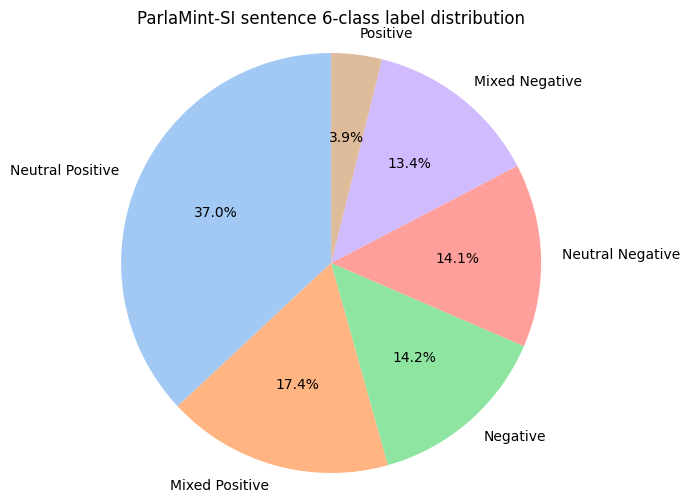

In [13]:
# Pie chart - 6-class labels
import matplotlib.pyplot as plt
import seaborn as sns

palette = sns.color_palette('pastel')

plt.figure(figsize=(8, 6))
plt.pie(labels_percentage, labels=labels_percentage.index, autopct='%1.1f%%', startangle=90, colors=palette)
plt.title('ParlaMint-SI sentence 6-class label distribution')
plt.axis('equal')
plt.savefig('../Figures/ParlaMint-SI_sentence_6class.png', dpi=300)
plt.show()

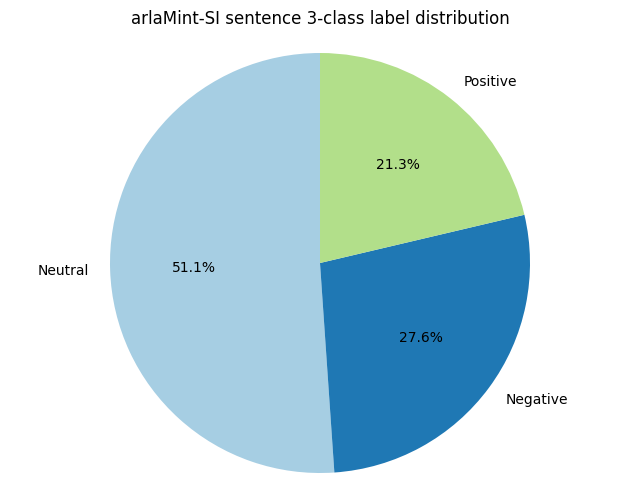

In [14]:
# Pie chart - 3-class labels
import matplotlib.pyplot as plt
import seaborn as sns

palette2 = sns.color_palette('Paired')

plt.figure(figsize=(8, 6))
plt.pie(sentiment_percentage, labels=sentiment_percentage.index, autopct='%1.1f%%', startangle=90, colors=palette2)
plt.title('arlaMint-SI sentence 3-class label distribution')
plt.axis('equal')
plt.savefig('../Figures/ParlaMint-SI_sentence_3class.png', dpi=300)
plt.show()

## Mapping for the utterance dataset [6-class schema]

In [15]:
df_utt = pd.read_csv('../Datasets/ParlaMint-SI_utt.tsv', sep='\t', encoding='utf-8')
df_utt

,ID,annotations
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,2.401479
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,2.805297
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u3,3.365201
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,3.148236
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u5,3.271888
...,...,...
311342,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u242,3.537891
311343,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u243,2.805739
311344,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u244,4.001848
311345,ParlaMint-SI_2005-01-24-SDZ4-Redna-02.ana.u245,2.460104


In [16]:
#Check for bounds
df_check = df_utt.sort_values(by=['annotations'], ascending=False)
df_check

,ID,annotations
39464,ParlaMint-SI_2014-05-21-SDZ6-Redna-25.ana.u147,5.452959
134911,ParlaMint-SI_2002-03-27-SDZ3-Redna-14.ana.u79,5.408666
16928,ParlaMint-SI_2009-05-20-SDZ5-Redna-06.ana.u168,5.301865
149211,ParlaMint-SI_2015-03-30-SDZ7-Redna-06.ana.u276,5.297259
233497,ParlaMint-SI_2007-09-25-SDZ4-Redna-31.ana.u137,5.253542
...,...,...
16438,ParlaMint-SI_2009-12-18-SDZ5-Redna-12.ana.u247,-0.051973
129182,ParlaMint-SI_2002-10-22-SDZ3-Redna-19.ana.u254,-0.057762
104947,ParlaMint-SI_2021-11-16-SDZ8-Redna-27.ana.u160,-0.063015
59721,ParlaMint-SI_2020-11-18-SDZ8-Izredna-48.ana.u363,-0.078793


In [17]:
label_mapping = {
    0: 'Negative',
    1: 'Mixed Negative',
    2: 'Neutral Negative',
    3: 'Neutral Positive',
    4: 'Mixed Positive',
    5: 'Positive'
}

annotations = np.clip(np.round(df_utt['annotations']), 0, 5).astype(int)
df_utt['annotations_clip'] = annotations
df_utt['labels'] = df_utt['annotations_clip'].map(label_mapping)
#df_sent = df_sent.drop(columns=['annotations_clip'])
df_utt.head()

,ID,annotations,annotations_clip,labels
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,2.401479,2,Neutral Negative
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,2.805297,3,Neutral Positive
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u3,3.365201,3,Neutral Positive
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,3.148236,3,Neutral Positive
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u5,3.271888,3,Neutral Positive


### Mapping to 3-class schema

In [18]:
#Mapping to 3-level scale
mapping = {
    0: 'Negative',
    1: 'Neutral',   
    2: 'Positive',
}

#df_utt['sentiment'] = df_utt['labels'].map(mapping)

sentiment = np.floor_divide(df_utt['annotations_clip'], 2)
df_utt['sentiment_no'] = sentiment
df_utt['sentiment'] = df_utt['sentiment_no'].map(mapping)
df_utt.head(15)

,ID,annotations,annotations_clip,labels,sentiment_no,sentiment
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,2.401479,2,Neutral Negative,1,Neutral
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,2.805297,3,Neutral Positive,1,Neutral
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u3,3.365201,3,Neutral Positive,1,Neutral
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,3.148236,3,Neutral Positive,1,Neutral
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u5,3.271888,3,Neutral Positive,1,Neutral
5,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u6,3.211051,3,Neutral Positive,1,Neutral
6,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u7,3.389189,3,Neutral Positive,1,Neutral
7,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u8,3.014766,3,Neutral Positive,1,Neutral
8,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u9,3.587602,4,Mixed Positive,2,Positive
9,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u10,3.446142,3,Neutral Positive,1,Neutral


In [19]:
df_utt = df_utt.drop(columns=['annotations_clip', 'sentiment_no'])
df_utt.head()

,ID,annotations,labels,sentiment
0,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u1,2.401479,Neutral Negative,Neutral
1,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u2,2.805297,Neutral Positive,Neutral
2,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u3,3.365201,Neutral Positive,Neutral
3,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u4,3.148236,Neutral Positive,Neutral
4,ParlaMint-SI_2022-04-06-SDZ8-Izredna-99.ana.u5,3.271888,Neutral Positive,Neutral


In [20]:
df_utt.to_csv('../Datasets/ParlaMint-SI/utt_labels.tsv', encoding='utf-8', sep='\t', index=False)

### Checking label distributions (6-class)

In [21]:
utt_labels = df_utt['labels'].value_counts()
utt_labels

labels
Neutral Positive    156602
Neutral Negative     70730
Mixed Positive       44383
Mixed Negative       36488
Negative              2663
Positive               481
Name: count, dtype: int64

In [22]:
utt_label_per = (utt_labels / utt_labels.sum()) * 100
utt_label_per

labels
Neutral Positive    50.298220
Neutral Negative    22.717418
Mixed Positive      14.255156
Mixed Negative      11.719400
Negative             0.855316
Positive             0.154490
Name: count, dtype: float64

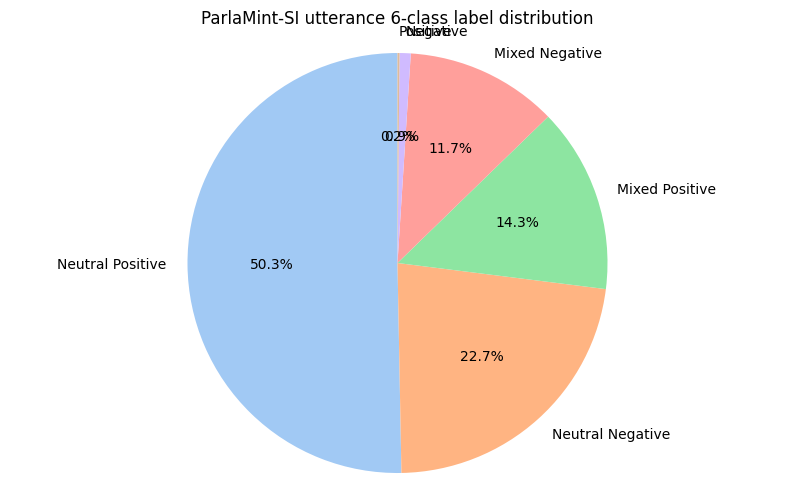

In [23]:
plt.figure(figsize=(10, 6))
plt.pie(utt_label_per, labels=utt_label_per.index, colors=palette, autopct='%1.1f%%', startangle=90)
plt.title('ParlaMint-SI utterance 6-class label distribution')
plt.axis('equal')
plt.savefig('../Figures/ParlaMint-SI_utterance_6class.png', dpi=300)
plt.show()

In [24]:
utt_sent = df_utt['sentiment'].value_counts()
utt_sent

sentiment
Neutral     227332
Positive     44864
Negative     39151
Name: count, dtype: int64

In [25]:
utt_sent_per = (utt_sent / utt_sent.sum()) * 100
utt_sent_per

sentiment
Neutral     73.015638
Positive    14.409646
Negative    12.574716
Name: count, dtype: float64

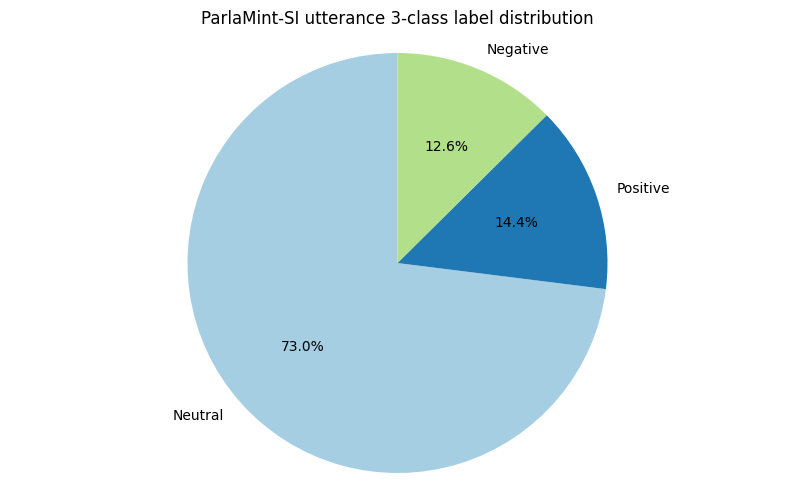

In [26]:
plt.figure(figsize=(10, 6))
plt.pie(utt_sent_per, labels=utt_sent_per.index, colors=palette2, autopct='%1.1f%%', startangle=90)
plt.title('ParlaMint-SI utterance 3-class label distribution')
plt.axis('equal')
plt.savefig('../Figures/ParlaMint-SI_utterance_3class.png', dpi=300)
plt.show()